<a href="https://colab.research.google.com/github/kjh0718-web/portfolio/blob/main/Python_%EA%B8%B0%EB%B0%98_Wafer_%ED%92%88%EC%A7%88_%EB%8D%B0%EC%9D%B4%ED%84%B0_%EB%B6%84%EC%84%9D_%EC%9E%90%EB%8F%99%ED%99%94.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 자동화된 웨이퍼 수율 및 결함 분석 파이프라인

## 사용 방법
1. 동일한 스키마를 가진 CSV 파일 6개를 `semiconductor_python_project/data/input/`. 경로에 넣습니다.
2. 클릭 **런타임→ Run all**.
3. output/ 경로 하위에 시각화 차트, CSV 테이블, Excel 리포트가 포함된 타임스탬프 이름의 새 폴더가 생성됩니다.

이 파이프라인은 입력된 배치 내에서 수율이 가장 낮은 웨이퍼를 자동으로 선정합니다. Lot/Wafer ID나 배치 이름을 별도로 수정할 필요가 없습니다.

In [ ]:
# Run once per Colab session
!pip -q install XlsxWriter

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.3/175.3 kB 4.4 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


입력 폴더: /content/drive/MyDrive/semiconductor_python_project/data/input
결과 저장 폴더: /content/drive/MyDrive/semiconductor_python_project/output/run_20260913_064929

입력 CSV 파일:
- 11. 설비 파라미터 table.csv
- 17. Recipe와 계측 상관성.csv
- 18. Recipe와 결함 상관성.csv
- 6. Wafer Defect map.csv
- 7. Wafer Bin Map.csv
- 8. CD Wafer Map.csv

데이터 로드 완료


,dataset,rows,columns
0,Wafer Bin Map,1075,9
1,Wafer Defect Map,1100,9
2,CD Wafer Map,425,9
3,Equipment Parameter Table,1501,12
4,Recipe-Measurement Data,25,10
5,Recipe-Defect Data,25,10



자동 분석 대상: TEST.1 / Wafer 12 | Yield=74.42%


,lot_id,wafer_id,total_die,good_die,bad_die,yield_pct,is_low_yield
11,TEST.1,12,43,32,11,74.42,True


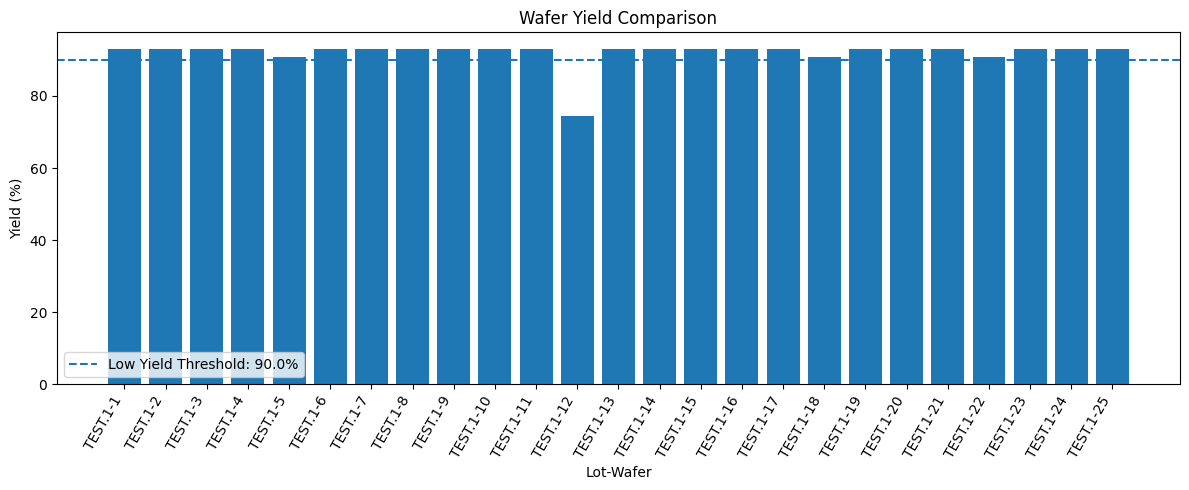

Yield vs Total Defect Count correlation: -0.979


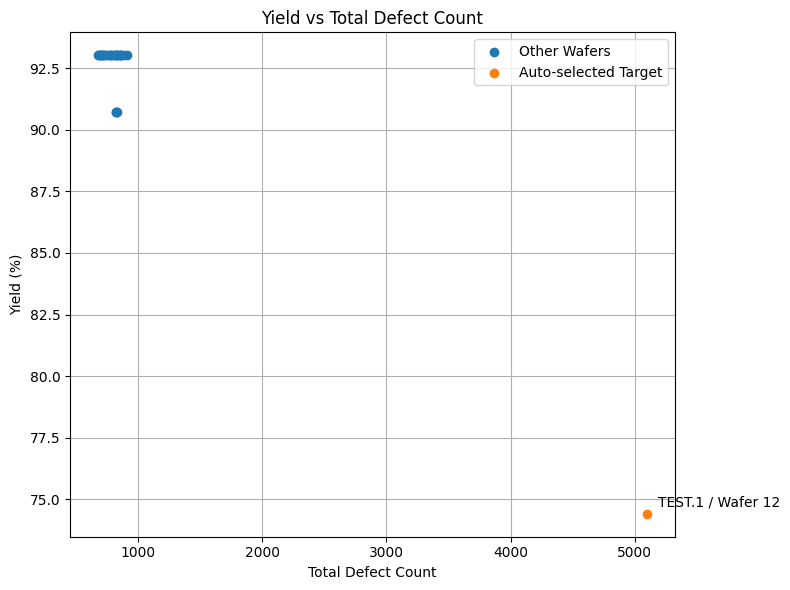

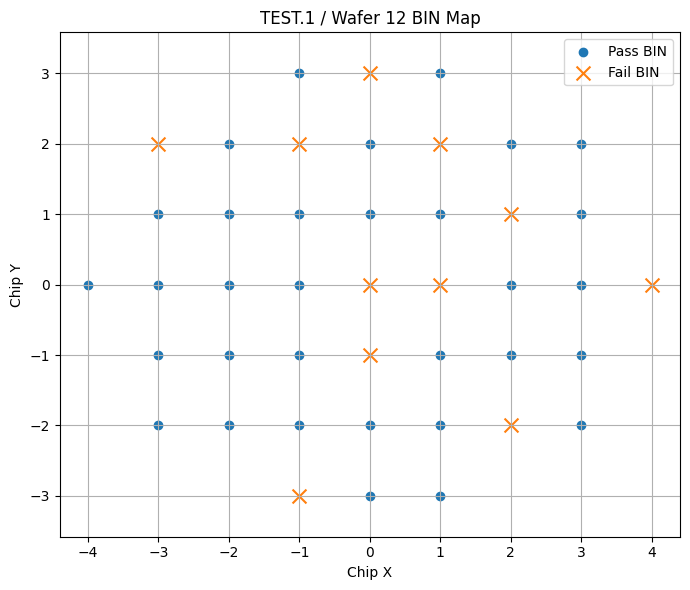

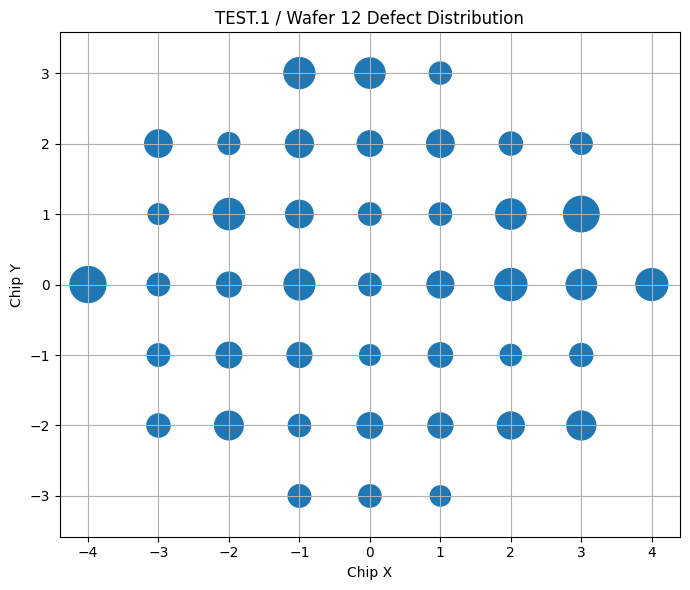

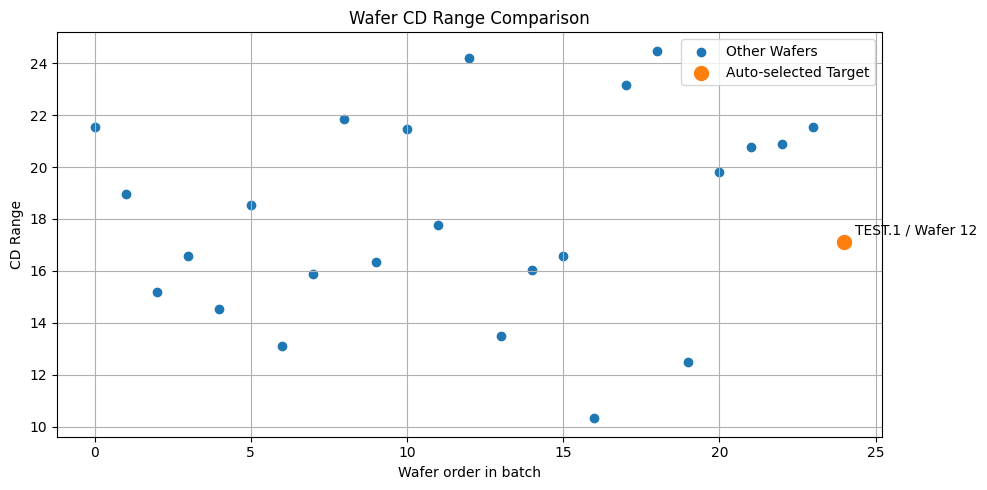


=== RUN COMPLETE ===
Auto-selected target: TEST.1 / Wafer 12
Output folder: /content/drive/MyDrive/semiconductor_python_project/output/run_20260913_064929
Excel report: /content/drive/MyDrive/semiconductor_python_project/output/run_20260913_064929/wafer_analysis_report.xlsx


,analysis_area,target_result,other_wafers_reference,interpretation,decision
0,Yield Screening,74.42%,92.73%,Lowest-yield wafer selected automatically,Primary analysis target
1,Defect Map,5100,788.57,Target total defect count compared with other ...,Candidate factor
2,CD Wafer Map,"Avg=108.32, Range=17.13","Avg=108.89, Range=18.15",CD level and uniformity comparison,Compare with defect finding
3,Main-etch Equipment,Main-etch Wafer-level sensor comparison completed,Wafer-level main-etch sensor statistics,Equipment analysis is conditional on available...,Supporting evidence
4,Recipe-Defect Data,ELO101 / F108CH_3K / 12.50%,1 abnormal / 8 total,Target wafer recipe-equipment risk rate calcul...,Supporting evidence
5,Recipe-Measurement Coverage,Not Measured,CD1/CD81 availability,Measurement availability checked before interp...,Data limitation check


In [ ]:

# Python-based Wafer Yield & Defect Analysis Pipeline
# Input: a folder containing the six standardized CSV files.
# Output: timestamped tables, figures, and an Excel report.

from pathlib import Path
from datetime import datetime
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display


def read_csv_safely(file_path: Path) -> pd.DataFrame:
    for encoding in ["utf-8-sig", "cp949", "euc-kr", "utf-8"]:
        try:
            return pd.read_csv(file_path, encoding=encoding)
        except UnicodeDecodeError:
            continue
    raise ValueError(f"파일 인코딩을 읽을 수 없습니다: {file_path.name}")


def normalize_id(series: pd.Series) -> pd.Series:
    return (
        series.astype(str)
        .str.strip()
        .str.replace(r"\.0$", "", regex=True)
    )


def clean_unnamed(df: pd.DataFrame) -> pd.DataFrame:
    return df.loc[:, ~df.columns.astype(str).str.startswith("Unnamed")].copy()


def get_file(input_path: Path, prefix: str) -> Path:
    matches = [f for f in input_path.glob("*.csv") if f.name.startswith(prefix)]
    if not matches:
        raise FileNotFoundError(f"'{prefix}'로 시작하는 CSV를 찾지 못했습니다: {input_path}")
    return matches[0]


# ------------------------------------------------------------
# 1. Fixed input/output paths
# ------------------------------------------------------------
ROOT = Path("/content/drive/MyDrive/semiconductor_python_project")
INPUT_PATH = ROOT / "data" / "input"
RUN_ID = datetime.now().strftime("run_%Y%m%d_%H%M%S")
OUTPUT_PATH = ROOT / "output" / RUN_ID
TABLE_PATH = OUTPUT_PATH / "tables"
FIGURE_PATH = OUTPUT_PATH / "figures"

for folder in [INPUT_PATH, OUTPUT_PATH, TABLE_PATH, FIGURE_PATH]:
    folder.mkdir(parents=True, exist_ok=True)

print("입력 폴더:", INPUT_PATH)
print("결과 저장 폴더:", OUTPUT_PATH)

required_prefixes = ["6.", "7.", "8.", "11.", "17.", "18."]
missing = [prefix for prefix in required_prefixes if not any(f.name.startswith(prefix) for f in INPUT_PATH.glob("*.csv"))]
if missing:
    raise FileNotFoundError(
        "입력 폴더에 필요한 CSV가 없습니다. 누락된 파일 번호: " + ", ".join(missing)
    )

print("\n입력 CSV 파일:")
for file in sorted(INPUT_PATH.glob("*.csv")):
    print("-", file.name)

# ------------------------------------------------------------
# 2. Load files
# ------------------------------------------------------------
file_map = {
    "bin": get_file(INPUT_PATH, "7."),
    "defect": get_file(INPUT_PATH, "6."),
    "cd": get_file(INPUT_PATH, "8."),
    "equipment": get_file(INPUT_PATH, "11."),
    "recipe_measure": get_file(INPUT_PATH, "17."),
    "recipe_defect": get_file(INPUT_PATH, "18."),
}

bin_raw = read_csv_safely(file_map["bin"])
defect_raw = read_csv_safely(file_map["defect"])
cd_raw = read_csv_safely(file_map["cd"])
eqp_raw = read_csv_safely(file_map["equipment"])
recipe_measure_raw = read_csv_safely(file_map["recipe_measure"])
recipe_defect_raw = read_csv_safely(file_map["recipe_defect"])

dataset_summary = pd.DataFrame({
    "dataset": ["Wafer Bin Map", "Wafer Defect Map", "CD Wafer Map", "Equipment Parameter Table", "Recipe-Measurement Data", "Recipe-Defect Data"],
    "rows": [len(bin_raw), len(defect_raw), len(cd_raw), len(eqp_raw), len(recipe_measure_raw), len(recipe_defect_raw)],
    "columns": [len(bin_raw.columns), len(defect_raw.columns), len(cd_raw.columns), len(eqp_raw.columns), len(recipe_measure_raw.columns), len(recipe_defect_raw.columns)],
})
print("\n데이터 로드 완료")
display(dataset_summary)

# ------------------------------------------------------------
# 3. Yield screening
# ------------------------------------------------------------
bin_df = clean_unnamed(bin_raw)
bin_df["lot_id"] = normalize_id(bin_df["lot_id"])
bin_df["wafer_id"] = normalize_id(bin_df["wafer_id"])
bin_df["value"] = pd.to_numeric(bin_df["value"], errors="coerce")
PASS_BINS = [1.0, 2.0]
bin_df["is_pass"] = bin_df["value"].isin(PASS_BINS)

wafer_yield = (
    bin_df.groupby(["lot_id", "wafer_id"], as_index=False)
    .agg(total_die=("value", "size"), good_die=("is_pass", "sum"))
)
wafer_yield["bad_die"] = wafer_yield["total_die"] - wafer_yield["good_die"]
wafer_yield["yield_pct"] = (wafer_yield["good_die"] / wafer_yield["total_die"] * 100).round(2)
LOW_YIELD_THRESHOLD = 90.0
wafer_yield["is_low_yield"] = wafer_yield["yield_pct"] < LOW_YIELD_THRESHOLD
wafer_yield["wafer_id_num"] = pd.to_numeric(wafer_yield["wafer_id"], errors="coerce")
wafer_yield = wafer_yield.sort_values(["lot_id", "wafer_id_num", "wafer_id"]).drop(columns="wafer_id_num").reset_index(drop=True)

# The analysis target is selected automatically: the lowest-yield wafer in the batch.
target_row = wafer_yield.sort_values("yield_pct", ascending=True).iloc[0]
TARGET_LOT = str(target_row["lot_id"])
TARGET_WAFER = str(target_row["wafer_id"])
TARGET_LABEL = f"{TARGET_LOT} / Wafer {TARGET_WAFER}"

print(f"\n자동 분석 대상: {TARGET_LABEL} | Yield={target_row['yield_pct']:.2f}%")
display(wafer_yield[wafer_yield["is_low_yield"]])

plt.figure(figsize=(12, 5))
wafer_labels = wafer_yield["lot_id"] + "-" + wafer_yield["wafer_id"]
plt.bar(wafer_labels, wafer_yield["yield_pct"])
plt.axhline(LOW_YIELD_THRESHOLD, linestyle="--", label=f"Low Yield Threshold: {LOW_YIELD_THRESHOLD}%")
plt.xlabel("Lot-Wafer")
plt.ylabel("Yield (%)")
plt.title("Wafer Yield Comparison")
plt.xticks(rotation=60, ha="right")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURE_PATH / "01_wafer_yield_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

# ------------------------------------------------------------
# 4. Defect analysis
# ------------------------------------------------------------
defect_df = clean_unnamed(defect_raw)
defect_df["lot_id"] = normalize_id(defect_df["lot_id"])
defect_df["wafer_id"] = normalize_id(defect_df["wafer_id"])
defect_df["value"] = pd.to_numeric(defect_df["value"], errors="coerce")
defect_chip_df = defect_df.dropna(subset=["chip_x", "chip_y"]).copy()

wafer_defect = (
    defect_chip_df.groupby(["lot_id", "wafer_id"], as_index=False)
    .agg(
        measured_die=("value", "size"),
        total_defect_count=("value", "sum"),
        avg_defect_per_die=("value", "mean"),
        max_defect_per_die=("value", "max"),
    )
)
wafer_defect[["avg_defect_per_die", "max_defect_per_die"]] = wafer_defect[["avg_defect_per_die", "max_defect_per_die"]].round(2)

yield_defect = wafer_yield.merge(wafer_defect, on=["lot_id", "wafer_id"], how="left")
correlation = yield_defect["yield_pct"].corr(yield_defect["total_defect_count"])
print(f"Yield vs Total Defect Count correlation: {correlation:.3f}")

normal_wafers = yield_defect[(yield_defect["lot_id"] != TARGET_LOT) | (yield_defect["wafer_id"] != TARGET_WAFER)]
target_wafers = yield_defect[(yield_defect["lot_id"] == TARGET_LOT) & (yield_defect["wafer_id"] == TARGET_WAFER)]
plt.figure(figsize=(8, 6))
plt.scatter(normal_wafers["total_defect_count"], normal_wafers["yield_pct"], label="Other Wafers")
plt.scatter(target_wafers["total_defect_count"], target_wafers["yield_pct"], label="Auto-selected Target")
for _, row in target_wafers.iterrows():
    plt.annotate(TARGET_LABEL, (row["total_defect_count"], row["yield_pct"]), xytext=(8, 5), textcoords="offset points")
plt.xlabel("Total Defect Count")
plt.ylabel("Yield (%)")
plt.title("Yield vs Total Defect Count")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig(FIGURE_PATH / "02_yield_vs_defect.png", dpi=300, bbox_inches="tight")
plt.show()

# Chip-level bin/defect join
bin_chip_df = bin_df[["lot_id", "wafer_id", "chip_x", "chip_y", "value", "is_pass"]].rename(columns={"value": "bin_value"})
defect_chip_for_merge = defect_chip_df[["lot_id", "wafer_id", "chip_x", "chip_y", "value"]].rename(columns={"value": "defect_count"})
chip_analysis = bin_chip_df.merge(defect_chip_for_merge, on=["lot_id", "wafer_id", "chip_x", "chip_y"], how="inner", validate="one_to_one")
chip_analysis["bin_result"] = chip_analysis["is_pass"].map({True: "Pass BIN", False: "Fail BIN"})

target_chip = chip_analysis[(chip_analysis["lot_id"] == TARGET_LOT) & (chip_analysis["wafer_id"] == TARGET_WAFER)].copy()
target_bin_defect_summary = (
    target_chip.groupby("bin_result", as_index=False)
    .agg(die_count=("defect_count", "size"), avg_defect=("defect_count", "mean"), median_defect=("defect_count", "median"), max_defect=("defect_count", "max"))
)
target_bin_defect_summary[["avg_defect", "median_defect", "max_defect"]] = target_bin_defect_summary[["avg_defect", "median_defect", "max_defect"]].round(2)

pass_chip = target_chip[target_chip["bin_result"] == "Pass BIN"]
fail_chip = target_chip[target_chip["bin_result"] == "Fail BIN"]
plt.figure(figsize=(7, 6))
plt.scatter(pass_chip["chip_x"], pass_chip["chip_y"], label="Pass BIN")
plt.scatter(fail_chip["chip_x"], fail_chip["chip_y"], marker="x", s=100, label="Fail BIN")
plt.xlabel("Chip X")
plt.ylabel("Chip Y")
plt.title(f"{TARGET_LABEL} BIN Map")
plt.grid(True)
plt.axis("equal")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURE_PATH / "03_target_bin_map.png", dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(7, 6))
plt.scatter(target_chip["chip_x"], target_chip["chip_y"], s=target_chip["defect_count"].clip(lower=0) * 3)
plt.xlabel("Chip X")
plt.ylabel("Chip Y")
plt.title(f"{TARGET_LABEL} Defect Distribution")
plt.grid(True)
plt.axis("equal")
plt.tight_layout()
plt.savefig(FIGURE_PATH / "04_target_defect_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

# ------------------------------------------------------------
# 5. CD analysis
# ------------------------------------------------------------
cd_df = clean_unnamed(cd_raw)
cd_df["lot_id"] = normalize_id(cd_df["lot_id"])
cd_df["wafer_id"] = normalize_id(cd_df["wafer_id"])
cd_df["value"] = pd.to_numeric(cd_df["value"], errors="coerce")
wafer_cd = (
    cd_df.groupby(["lot_id", "wafer_id"], as_index=False)
    .agg(cd_measure_count=("value", "size"), avg_cd=("value", "mean"), std_cd=("value", "std"), min_cd=("value", "min"), max_cd=("value", "max"))
)
wafer_cd["cd_range"] = wafer_cd["max_cd"] - wafer_cd["min_cd"]
wafer_cd[["avg_cd", "std_cd", "min_cd", "max_cd", "cd_range"]] = wafer_cd[["avg_cd", "std_cd", "min_cd", "max_cd", "cd_range"]].round(2)

yield_defect_cd = yield_defect.merge(wafer_cd, on=["lot_id", "wafer_id"], how="left")
normal_cd = yield_defect_cd[(yield_defect_cd["lot_id"] != TARGET_LOT) | (yield_defect_cd["wafer_id"] != TARGET_WAFER)]
target_cd = yield_defect_cd[(yield_defect_cd["lot_id"] == TARGET_LOT) & (yield_defect_cd["wafer_id"] == TARGET_WAFER)]

plt.figure(figsize=(10, 5))
plt.scatter(range(len(normal_cd)), normal_cd["cd_range"], label="Other Wafers")
plt.scatter([len(normal_cd)], target_cd["cd_range"], s=100, label="Auto-selected Target")
plt.annotate(TARGET_LABEL, (len(normal_cd), target_cd["cd_range"].iloc[0]), xytext=(8, 5), textcoords="offset points")
plt.xlabel("Wafer order in batch")
plt.ylabel("CD Range")
plt.title("Wafer CD Range Comparison")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig(FIGURE_PATH / "05_cd_range_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

# ------------------------------------------------------------
# 6. Equipment analysis: optional if main-etch exists
# ------------------------------------------------------------
eqp_df = clean_unnamed(eqp_raw)
eqp_df["lot_id"] = normalize_id(eqp_df["lot_id"])
eqp_df["wafer_id"] = normalize_id(eqp_df["wafer_id"])
for col in ["precursor_flow_rate", "chamber_pressure", "rf_power", "reflect_power"]:
    eqp_df[col] = pd.to_numeric(eqp_df[col], errors="coerce")
eqp_clean = eqp_df[(~eqp_df["lot_id"].isin(["-", "nan", "None", ""])) & (~eqp_df["wafer_id"].isin(["-", "nan", "None", ""]))].copy()
main_etch = eqp_clean[(eqp_clean["lot_id"] == TARGET_LOT) & (eqp_clean["chamber_step"].astype(str).str.lower() == "main-etch")].copy()
equipment_comparison = pd.DataFrame()
equipment_note = "Main-etch 로그가 없어 설비 비교를 수행하지 못함"
if not main_etch.empty:
    main_etch_summary = (
        main_etch.groupby("wafer_id", as_index=False)
        .agg(
            log_count=("wafer_id", "size"), flow_mean=("precursor_flow_rate", "mean"), pressure_mean=("chamber_pressure", "mean"),
            rf_mean=("rf_power", "mean"), rf_std=("rf_power", "std"), reflect_mean=("reflect_power", "mean"),
            reflect_std=("reflect_power", "std"), reflect_max=("reflect_power", "max"),
        )
    )
    target_main = main_etch_summary[main_etch_summary["wafer_id"] == TARGET_WAFER]
    other_main = main_etch_summary[main_etch_summary["wafer_id"] != TARGET_WAFER]
    if not target_main.empty and not other_main.empty:
        metrics = ["flow_mean", "pressure_mean", "rf_mean", "rf_std", "reflect_mean", "reflect_std", "reflect_max"]
        equipment_comparison = pd.DataFrame({
            "metric": metrics,
            "other_wafers_median": [other_main[m].median() for m in metrics],
            "other_wafers_mean": [other_main[m].mean() for m in metrics],
            "target_value": [target_main[m].iloc[0] for m in metrics],
            "target_percentile": [(other_main[m] < target_main[m].iloc[0]).mean() * 100 for m in metrics],
        }).round(2)
        equipment_note = "Main-etch Wafer-level sensor comparison completed"

# ------------------------------------------------------------
# 7. Recipe defect risk: optional
# ------------------------------------------------------------
recipe_defect_df = clean_unnamed(recipe_defect_raw)
for col in ["lot_id", "wafer_id", "step_sequence", "step_description", "eqp_id", "recipe_id", "defect_result"]:
    recipe_defect_df[col] = normalize_id(recipe_defect_df[col])
recipe_defect_unique = recipe_defect_df.drop_duplicates(subset=["lot_id", "wafer_id", "step_sequence", "step_description", "eqp_id", "recipe_id"]).copy()
recipe_defect_unique["is_abnormal"] = recipe_defect_unique["defect_result"] != "good"
recipe_risk_summary = (
    recipe_defect_unique.groupby(["step_description", "eqp_id", "recipe_id"], as_index=False)
    .agg(total_wafers=("wafer_id", "size"), abnormal_wafers=("is_abnormal", "sum"))
)
recipe_risk_summary["abnormal_rate_pct"] = (recipe_risk_summary["abnormal_wafers"] / recipe_risk_summary["total_wafers"] * 100).round(2)
recipe_risk_summary = recipe_risk_summary.sort_values(["abnormal_rate_pct", "abnormal_wafers"], ascending=False).reset_index(drop=True)
target_recipe_condition = recipe_defect_unique[(recipe_defect_unique["lot_id"] == TARGET_LOT) & (recipe_defect_unique["wafer_id"] == TARGET_WAFER)][["step_description", "eqp_id", "recipe_id", "defect_result"]].copy()
target_recipe_risk = target_recipe_condition.merge(recipe_risk_summary, on=["step_description", "eqp_id", "recipe_id"], how="left")

# ------------------------------------------------------------
# 8. Recipe measurement coverage: optional
# ------------------------------------------------------------
recipe_measure_df = clean_unnamed(recipe_measure_raw)
for col in ["lot_id", "wafer_id", "step_sequence", "step_description", "eqp_id", "recipe_id"]:
    recipe_measure_df[col] = normalize_id(recipe_measure_df[col])
for col in ["CD1", "CD81", "Avg(value)"]:
    recipe_measure_df[col] = pd.to_numeric(recipe_measure_df[col], errors="coerce")
measurement_coverage = (
    recipe_measure_df[recipe_measure_df["lot_id"] == TARGET_LOT]
    .groupby("wafer_id", as_index=False)
    .agg(measurement_available=("Avg(value)", lambda x: x.notna().any()))
)
measurement_coverage["measurement_status"] = measurement_coverage["measurement_available"].map({True: "Measured", False: "Not Measured"})
target_measurement_status = measurement_coverage[measurement_coverage["wafer_id"] == TARGET_WAFER]

# ------------------------------------------------------------
# 9. Summary + exports
# ------------------------------------------------------------
target_master = yield_defect_cd[(yield_defect_cd["lot_id"] == TARGET_LOT) & (yield_defect_cd["wafer_id"] == TARGET_WAFER)].iloc[0]
normal_master = yield_defect_cd[(yield_defect_cd["lot_id"] != TARGET_LOT) | (yield_defect_cd["wafer_id"] != TARGET_WAFER)].copy()
normal_yield = normal_master["yield_pct"].mean()
normal_defect = normal_master["total_defect_count"].mean()
normal_cd = normal_master["avg_cd"].mean()
normal_cd_range = normal_master["cd_range"].mean()

recipe_result = "No matching recipe record"
recipe_reference = "-"
recipe_interpretation = "Recipe-Defect record not available for target wafer"
if not target_recipe_risk.empty:
    rec = target_recipe_risk.iloc[0]
    recipe_result = f"{rec['eqp_id']} / {rec['recipe_id']} / {rec['abnormal_rate_pct']:.2f}%"
    recipe_reference = f"{rec['abnormal_wafers']:.0f} abnormal / {rec['total_wafers']:.0f} total"
    recipe_interpretation = "Target wafer recipe-equipment risk rate calculated from Recipe-Defect data"

measure_status = "No coverage record"
if not target_measurement_status.empty:
    measure_status = target_measurement_status["measurement_status"].iloc[0]

final_summary = pd.DataFrame([
    {"analysis_area": "Yield Screening", "target_result": f"{target_master['yield_pct']:.2f}%", "other_wafers_reference": f"{normal_yield:.2f}%", "interpretation": "Lowest-yield wafer selected automatically", "decision": "Primary analysis target"},
    {"analysis_area": "Defect Map", "target_result": f"{target_master['total_defect_count']:.0f}", "other_wafers_reference": f"{normal_defect:.2f}", "interpretation": "Target total defect count compared with other wafers", "decision": "Candidate factor"},
    {"analysis_area": "CD Wafer Map", "target_result": f"Avg={target_master['avg_cd']:.2f}, Range={target_master['cd_range']:.2f}", "other_wafers_reference": f"Avg={normal_cd:.2f}, Range={normal_cd_range:.2f}", "interpretation": "CD level and uniformity comparison", "decision": "Compare with defect finding"},
    {"analysis_area": "Main-etch Equipment", "target_result": equipment_note, "other_wafers_reference": "Wafer-level main-etch sensor statistics", "interpretation": "Equipment analysis is conditional on available main-etch logs", "decision": "Supporting evidence"},
    {"analysis_area": "Recipe-Defect Data", "target_result": recipe_result, "other_wafers_reference": recipe_reference, "interpretation": recipe_interpretation, "decision": "Supporting evidence"},
    {"analysis_area": "Recipe-Measurement Coverage", "target_result": measure_status, "other_wafers_reference": "CD1/CD81 availability", "interpretation": "Measurement availability checked before interpretation", "decision": "Data limitation check"},
])

# tables
dataset_summary.to_csv(TABLE_PATH / "dataset_summary.csv", index=False, encoding="utf-8-sig")
yield_defect_cd.to_csv(TABLE_PATH / "wafer_yield_defect_cd_summary.csv", index=False, encoding="utf-8-sig")
target_bin_defect_summary.to_csv(TABLE_PATH / "target_bin_defect_summary.csv", index=False, encoding="utf-8-sig")
final_summary.to_csv(TABLE_PATH / "final_analysis_summary.csv", index=False, encoding="utf-8-sig")
measurement_coverage.to_csv(TABLE_PATH / "measurement_coverage.csv", index=False, encoding="utf-8-sig")
recipe_risk_summary.to_csv(TABLE_PATH / "recipe_risk_summary.csv", index=False, encoding="utf-8-sig")
if not equipment_comparison.empty:
    equipment_comparison.to_csv(TABLE_PATH / "main_etch_equipment_comparison.csv", index=False, encoding="utf-8-sig")

# Excel report
try:
    import xlsxwriter
except ImportError:
    !pip -q install XlsxWriter

report_path = OUTPUT_PATH / "wafer_analysis_report.xlsx"
with pd.ExcelWriter(report_path, engine="xlsxwriter") as writer:
    final_summary.to_excel(writer, sheet_name="Analysis Summary", startrow=5, index=False)
    yield_defect_cd.to_excel(writer, sheet_name="Wafer Master Table", index=False)
    measurement_coverage.to_excel(writer, sheet_name="Measurement Coverage", index=False)
    recipe_risk_summary.to_excel(writer, sheet_name="Recipe Risk", index=False)
    if not equipment_comparison.empty:
        equipment_comparison.to_excel(writer, sheet_name="Equipment Comparison", index=False)

    workbook = writer.book
    title_format = workbook.add_format({"bold": True, "font_size": 18})
    subtitle_format = workbook.add_format({"bold": True, "font_size": 11})
    header_format = workbook.add_format({"bold": True, "bg_color": "#D9EAF7", "border": 1, "align": "center", "valign": "vcenter"})
    text_wrap_format = workbook.add_format({"text_wrap": True, "valign": "top"})

    summary_ws = writer.sheets["Analysis Summary"]
    summary_ws.write("A1", "Automated Wafer Yield Analysis Report", title_format)
    summary_ws.write("A2", f"Input batch: {INPUT_PATH.name} | Target: {TARGET_LABEL}", subtitle_format)
    summary_ws.write("A4", "Final Analysis Summary", subtitle_format)
    for col_num, value in enumerate(final_summary.columns):
        summary_ws.write(5, col_num, value, header_format)
    summary_ws.set_column("A:A", 30)
    summary_ws.set_column("B:C", 32)
    summary_ws.set_column("D:D", 55)
    summary_ws.set_column("E:E", 25)
    summary_ws.freeze_panes(6, 0)

    master_ws = writer.sheets["Wafer Master Table"]
    for col_num, value in enumerate(yield_defect_cd.columns):
        master_ws.write(0, col_num, value, header_format)
    master_ws.freeze_panes(1, 0)
    master_ws.set_column(0, len(yield_defect_cd.columns)-1, 16)
    yield_col = yield_defect_cd.columns.get_loc("yield_pct")
    master_ws.conditional_format(1, yield_col, len(yield_defect_cd), yield_col, {"type": "3_color_scale"})

    for sheet_name, df in [("Measurement Coverage", measurement_coverage), ("Recipe Risk", recipe_risk_summary)]:
        ws = writer.sheets[sheet_name]
        for col_num, value in enumerate(df.columns):
            ws.write(0, col_num, value, header_format)
        ws.freeze_panes(1, 0)
        ws.set_column(0, len(df.columns)-1, 20)

    if not equipment_comparison.empty:
        ws = writer.sheets["Equipment Comparison"]
        for col_num, value in enumerate(equipment_comparison.columns):
            ws.write(0, col_num, value, header_format)
        ws.freeze_panes(1, 0)
        ws.set_column(0, len(equipment_comparison.columns)-1, 20)

    figures_ws = workbook.add_worksheet("Figures")
    figures_ws.write("A1", "Key Analysis Figures", title_format)
    figure_list = [
        ("01_wafer_yield_comparison.png", "1. Wafer Yield Comparison", "A3"),
        ("02_yield_vs_defect.png", "2. Yield vs Total Defect Count", "J3"),
        ("03_target_bin_map.png", "3. Target BIN Map", "A28"),
        ("04_target_defect_distribution.png", "4. Target Defect Distribution", "J28"),
        ("05_cd_range_comparison.png", "5. CD Range Comparison", "A53"),
    ]
    for filename, caption, position in figure_list:
        col = position[0]
        row = int(position[1:])
        figures_ws.write(f"{col}{row-1}", caption, subtitle_format)
        figures_ws.insert_image(position, str(FIGURE_PATH / filename), {"x_scale": 0.55, "y_scale": 0.55})
    figures_ws.set_column("A:R", 12)

    notes_ws = workbook.add_worksheet("Run Notes")
    notes = [
        ["Item", "Value"],
        ["Input Folder", str(INPUT_PATH)],
        ["Run ID", RUN_ID],
        ["Auto-selected Target", TARGET_LABEL],
        ["Target Yield", f"{target_master['yield_pct']:.2f}%"],
        ["Automation Scope", "Replace the six same-schema CSV files in data/input, then run all cells. The pipeline automatically selects the lowest-yield wafer, creates figures, CSV tables, and an Excel report."],
        ["Limitation", "Colab does not run automatically merely because a file is uploaded. One Run all action is required unless an external scheduler/cloud workflow is added."],
    ]
    for r, row in enumerate(notes):
        for c, value in enumerate(row):
            notes_ws.write(r, c, value, header_format if r == 0 else text_wrap_format)
    notes_ws.set_column("A:A", 28)
    notes_ws.set_column("B:B", 105)

print("\n=== RUN COMPLETE ===")
print("Auto-selected target:", TARGET_LABEL)
print("Output folder:", OUTPUT_PATH)
print("Excel report:", report_path)
display(final_summary)
